In [2]:
# =============================================================================
# Saben la propietat commutativa? a x b vs b x a  (A998, Espanya, curs 2025-26)
# =============================================================================
# PREGUNTA: els alumnes tracten a x b i b x a com el mateix fet? I si no, els va
# millor quan el factor GRAN va primer o quan va segon?
#
# PER QUE NO N'HI HA PROU AMB heatmap(a,b) - heatmap(b,a) --------------------
# Restar dues marginals de poblacio (el que donaria el heatmap de fets de
# hardest_table.ipynb) es vulnerable a un artefacte d'agregacio (d'aire
# paradoxa de Simpson): si uns alumnes encerten a x b i falles b x a, i ALTRES
# alumnes fan el contrari, les dues taxes poblacionals surten iguals i la
# diferencia s'esvaeix -- tot i que cap alumne individual tracta les dues com
# equivalents. Les marginals es calculen sobre conjunts d'alumnes DIFERENTS a
# cada costat de la resta, aixi que la seva diferencia no respon una pregunta
# intra-alumne.
#
# SOLUCIO: aparellar cada alumne amb ELL MATEIX. Per cada alumne que hagi
# intentat les DUES direccions d'una parella durant l'any (no cal el mateix dia
# ni la mateixa sessio), es calculen les seves dues precisions i la diferencia.
# La potencia estadistica ve de tenir MOLTS ALUMNES per edat (34k a edat 8, 2k
# a edat 15), no de molts intents per alumne -- que es precisament el que fa
# viable aquesta via, donat que cada nen fa la prova ~3 cops l'any 1.5-2 min.
#
# ELS DOS NUMEROS S'HAN DE LLEGIR JUNTS -------------------------------------
#   mean_diff      diferencia SIGNADA mitjana (acc_gran_primer - acc_gran_segon)
#                  Positiu => els va millor amb el factor GRAN primer.
#   mean_abs_diff  mitjana de |diferencia|: mida del desacord intra-alumne,
#                  independentment de la direccio. AIXO ES EL QUE LA RESTA DE
#                  MARGINALS NO POT VEURE: si mean_diff ~ 0 pero mean_abs_diff
#                  es gran, hi ha alumnes que SI responen diferent a cada
#                  direccio i simplement es cancel·len entre ells en agregar.
#                  Nomes quan TOTS DOS son ~0 podem dir que la direccio ha
#                  deixat d'importar a aquella edat.
#
# LES MATEIXES DADES COM A REPARTIMENT D'ALUMNES (afegit 2026-07-30) ---------
# mean_diff i mean_abs_diff son mitjanes d'una quantitat continua per alumne, i
# aixo amaga QUANTS alumnes hi ha a cada cas qualitativament diferent. Per aixo
# la query torna tambe quatre grups exclusius i exhaustius (sumen 100%):
#   pct_both_right       encerten TOTS els intents en LES DUES direccions
#   pct_only_big_first   perfectes amb el gran primer, no amb el gran segon
#   pct_only_big_second  perfectes amb el gran segon, no amb el gran primer
#   pct_neither_right    no son perfectes en cap de les dues
# Els dos del mig son els alumnes que NO tracten a x b i b x a com el mateix
# fet: la seva SUMA es la taxa de desacord de direccio i la seva DIFERENCIA es
# el biaix de direccio -- la versio discreta de mean_abs_diff i mean_diff.
# "Encertar una direccio" = acc = 1.0 en aquella direccio (acordat 2026-07-30),
# no acc > 0.5: amb MIN_ATTEMPTS = 1 gairebe tots els alumnes tenen un sol
# intent per direccio, aixi que les dues definicions coincideixen per a la
# immensa majoria de la mostra. Mateix caveat que mean_abs_diff: un despiste
# puntual treu un alumne de pct_both_right, aixi que els dos "only" son una
# COTA SUPERIOR del desacord real -- fia't de la tendencia, no del nivell.
#
# NOMES PRECISIO, NO VELOCITAT: la commutativa es una propietat del RESULTAT,
# aixi que aqui nomes es mira encert. El temps de resposta queda fora a proposit.
import re
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# =============================================================================
# >>>>>>>>>>>>>>>>>>>>>>>>  PARAMETRE PRINCIPAL  <<<<<<<<<<<<<<<<<<<<<<<<<<<<<
# Minim d'intents que un alumne ha de tenir EN CADA DIRECCIO per entrar a una
# casella (parella, edat). Canvia'l aqui i torna a executar el notebook.
#
#   1 -> permissiu (acordat 2026-07-29): mostra maxima, pero un alumne amb un
#        sol intent per direccio nomes pot donar diff = 0, +1 o -1, aixi que
#        mean_abs_diff s'infla amb soroll per intent.
#   2+ -> mes fiable per alumne (acc pot ser fraccionaria, el soroll baixa),
#        pero perd alumnes i caselles senceres a les edats amb menys mostra.
MIN_ATTEMPTS_PER_DIRECTION = 1

# Cursos escolars a incloure. NOMES ES_2025 (decidit 2026-07-30): les
# tendencies de ES_2024 queden fora de tots els grafics del notebook. La
# mecanica de substitucio del marcador -- {YEARS} del .sql es manté intacta,
# aixi que tornar a afegir ES_2024 -- i amb ell la lectura de replicacio entre
# cohorts, que era l'unic que aportava -- es nomes posar-lo a aquesta llista i
# re-executar. Amb un sol any a la llista, academic_year_id deixa de ser una
# dimensio dels resums: tot s'agrega per edat.
# ES_2022 i ES_2023 existeixen pero nomes cobreixen 2 mesos cada un (abr-jun 2023
# i gen-feb 2024), aixi que no son anys comparables i no entren mai per defecte.
#
# L'EDAT surt de `fluency_test_metrics.classroom_course_age`, que es un SNAPSHOT
# PER SESSIO i no un lookup contra el dimension viu -- verificat 2026-07-29:
# dels ~96.9k alumnes amb sessions A998 als dos anys, 96.178 (99,3%) tenen
# age(ES_2025)-age(ES_2024)=+1, com ha de ser si cada fila porta l'edat del
# moment de la seva propia sessio. Per tant NO cal el dimension _historic que
# avisava la memoria del projecte, ni ara amb un any ni si se n'hi afegeixen.
YEARS = ["ES_2025"]
# =============================================================================

HERE = Path.cwd()          # descriptive/ or mechanistic/ (run the notebook from its own folder)
ROOT = HERE
while not (ROOT / "databricks_connector.py").exists():
    if ROOT == ROOT.parent:
        raise FileNotFoundError("databricks_connector.py not found in any parent directory")
    ROOT = ROOT.parent      # repo root -- holds databricks_connector.py and cached_query.py
sys.path.insert(0, str(ROOT))
from cached_query import cached_query
(HERE / "cache").mkdir(exist_ok=True)
(HERE / "plots").mkdir(exist_ok=True)

SQL_PATH = HERE / "queries" / "a998_commutativity_paired_by_age.sql"
CACHE_DIR = HERE / "cache"

# El .sql porta el default (>= 1) escrit als dos HAVING marcats amb
# "-- {MIN_ATTEMPTS}", aixi que el fitxer segueix sent executable sol. Aqui es
# reescriuen tots dos segons MIN_ATTEMPTS_PER_DIRECTION. Si els marcadors
# desapareguessin del .sql, aixo peta -- millor petar que executar silenciosament
# un llindar diferent del que diu el notebook.
sql_raw = SQL_PATH.read_text(encoding="utf-8")
sql_text, n_subs = re.subn(r">= \d+(\s*-- \{MIN_ATTEMPTS\})",
                            f">= {MIN_ATTEMPTS_PER_DIRECTION}\\1", sql_raw)
assert n_subs == 2, (f"Esperava 2 marcadors -- {{MIN_ATTEMPTS}} al .sql, n'he trobat {n_subs}. "
                     "Han canviat els HAVING de a998_commutativity_paired_by_age.sql?")

years_sql = ", ".join(f"'{y}'" for y in YEARS)
sql_text, n_y = re.subn(r"IN \([^)]*\)(\s*-- \{YEARS\})",
                         f"IN ({years_sql})\\1", sql_text)
assert n_y == 1, (f"Esperava 1 marcador -- {{YEARS}} al .sql, n'he trobat {n_y}. "
                  "Ha canviat el filtre academic_year_id?")

com = cached_query(SQL_PATH, CACHE_DIR, sql_text=sql_text)

print("A998 | commutativitat aparellada intra-alumne")
print(f"YEARS = {YEARS} | MIN_ATTEMPTS_PER_DIRECTION = {MIN_ATTEMPTS_PER_DIRECTION}")
print("Direccio: 'gran primer' = factor gran escrit primer (8x7) | 'gran segon' = (7x8)")
print(f"Files: {len(com):,} (any x parella lo<hi x edat) | cache -> {CACHE_DIR.relative_to(ROOT)}/")
print(f"Parelles: {com.groupby(['lo','hi']).ngroups} | edats: {sorted(com['classroom_course_age'].unique())}")
assert com["academic_year_id"].nunique() == len(YEARS), "La query ha tornat anys que no son a YEARS"
print(f"Columnes de repartiment: {[c for c in com.columns if c.startswith('pct_')]}")

A998 | commutativitat aparellada intra-alumne
YEARS = ['ES_2025'] | MIN_ATTEMPTS_PER_DIRECTION = 1
Direccio: 'gran primer' = factor gran escrit primer (8x7) | 'gran segon' = (7x8)
Files: 355 (any x parella lo<hi x edat) | cache -> descriptive\cache/
Parelles: 45 | edats: [np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15)]
Columnes de repartiment: ['pct_both_right', 'pct_only_big_first', 'pct_only_big_second', 'pct_neither_right']


In [3]:
# --- factibilitat: hi ha prou alumnes aparellats per casella? --------------
# Comprovacio previa (abans de creure's cap numero): quants alumnes aporten una
# observacio aparellada a cada (parella, edat).
MIN_STUDENTS = 100

print("Alumnes aparellats per casella (any x parella x edat):")
print(com["n_students"].describe().round(1))

thin = com[com["n_students"] < MIN_STUDENTS]
print(f"\n{len(thin)} / {len(com)} caselles amb < {MIN_STUDENTS} alumnes aparellats -- s'exclouen.")
print("Concentrades a (any x edat):")
print(thin.groupby(["academic_year_id", "classroom_course_age"]).size().to_string())

print("\nIntents per alumne i casella (mitjana):")
print(com["n_attempts_per_student_avg"].describe().round(2))
print("~2.2 => la gran majoria d'alumnes tenen NOMES 1 intent per direccio.")

Alumnes aparellats per casella (any x parella x edat):
count      355.0
mean      1863.5
std       2085.7
min          1.0
25%        620.0
50%       1176.0
75%       2248.5
max      18591.0
Name: n_students, dtype: float64

12 / 355 caselles amb < 100 alumnes aparellats -- s'exclouen.
Concentrades a (any x edat):
academic_year_id  classroom_course_age
ES_2025           8                       12

Intents per alumne i casella (mitjana):
count    355.00
mean       2.35
std        0.24
min        2.00
25%        2.27
50%        2.30
75%        2.34
max        3.93
Name: n_attempts_per_student_avg, dtype: float64
~2.2 => la gran majoria d'alumnes tenen NOMES 1 intent per direccio.


In [4]:
# --- resum per edat: les mitjanes i el repartiment d'alumnes --------------
com = com.copy()
valid = com[com["n_students"] >= MIN_STUDENTS].copy()

PCT_COLS = ["pct_both_right", "pct_only_big_first", "pct_only_big_second",
            "pct_neither_right"]

# Tot ponderat per alumnes: dins d'una edat, una parella amb 25k alumnes
# aparellats no pot pesar igual que una amb 200.
def wavg(g, col):
    return np.average(g[col], weights=g["n_students"])

summary = (valid.groupby("classroom_course_age")
                .apply(lambda g: pd.Series({
                    "n_parelles": len(g),
                    "alumnes": g["n_students"].sum(),
                    "acc_gran_primer": wavg(g, "acc_big_first"),
                    "acc_gran_segon": wavg(g, "acc_big_second"),
                    "mean_diff": wavg(g, "mean_diff"),
                    "mean_abs_diff": wavg(g, "mean_abs_diff"),
                    **{c: wavg(g, c) for c in PCT_COLS},
                }), include_groups=False))

print(f"Resum per edat ({', '.join(YEARS)}, ponderat per alumnes):")
print(summary[["n_parelles", "alumnes", "acc_gran_primer", "acc_gran_segon",
               "mean_diff", "mean_abs_diff"]].round(4).to_string())

# Els quatre grups han de sumar 100 per construccio; si no, la query no reparteix
# els alumnes com diu que els reparteix i el panell de percentatges no vol dir res.
assert np.allclose(summary[PCT_COLS].sum(axis=1), 100, atol=0.05), \
    "Els quatre grups no sumen 100 -- revisa la particio de la query"

pcts = summary[PCT_COLS].copy()
pcts["desacord_only+only"] = (summary["pct_only_big_first"]
                              + summary["pct_only_big_second"])
print("\n% d'alumnes aparellats per cas (suma 100 per construccio):")
print(pcts.round(2).to_string())

a_lo, a_hi = summary.index.min(), summary.index.max()
r_lo, r_hi = summary.loc[a_lo], summary.loc[a_hi]

print("\n>>> LECTURA PRINCIPAL")
print("mean_diff es un ordre de magnitud mes petit que mean_abs_diff a TOTES les")
print(f"edats (a edat {a_lo}: {r_lo['mean_diff']:+.4f} vs {r_lo['mean_abs_diff']:.4f}), i el signe es")
print("sempre lleugerament negatiu: hi ha, com a molt, un biaix de direccio")
print("minuscul i a favor del factor GRAN SEGON (7x8 una mica millor que 8x7),")
print("mentre que el desacord intra-alumne es molt mes gran. Aixo es l'efecte que")
print("et preocupava: una resta de marginals hauria donat ~0 i s'hauria llegit com")
print("'ja se saben la commutativa', quan de fet els alumnes SI responen les dues")
print("direccions diferent -- nomes que uns cap a un costat i uns cap a l'altre,")
print("cancel.lant-se en agregat.")
print(f"\nmean_abs_diff baixa de {r_lo['mean_abs_diff']:.3f} (edat {a_lo}) a "
      f"{r_hi['mean_abs_diff']:.3f} (edat {a_hi}) => el desacord")
print("es redueix amb l'edat, pero no arriba a zero.")

print("\n>>> EL MATEIX EN ALUMNES (el que es dibuixa al panell 3 de la tendencia)")
print(f"Edat {a_lo}: {r_lo['pct_both_right']:.1f}% encerten les dues direccions, "
      f"{r_lo['pct_only_big_first'] + r_lo['pct_only_big_second']:.1f}% nomes una")
print(f"         ({r_lo['pct_only_big_first']:.1f}% nomes gran primer + "
      f"{r_lo['pct_only_big_second']:.1f}% nomes gran segon), "
      f"{r_lo['pct_neither_right']:.1f}% cap.")
print(f"Edat {a_hi}: {r_hi['pct_both_right']:.1f}% les dues, "
      f"{r_hi['pct_only_big_first'] + r_hi['pct_only_big_second']:.1f}% nomes una "
      f"({r_hi['pct_only_big_first']:.1f}% + {r_hi['pct_only_big_second']:.1f}%), "
      f"{r_hi['pct_neither_right']:.1f}% cap.")
print("Les dues corbes 'nomes una direccio' son gairebe simetriques a cada edat:")
print("es la mateixa cancel.lacio de signes, ara comptada en alumnes.")


Resum per edat (ES_2025, ponderat per alumnes):
                      n_parelles   alumnes  acc_gran_primer  acc_gran_segon  mean_diff  mean_abs_diff
classroom_course_age                                                                                 
8                           28.0  140158.0           0.4147          0.4353    -0.0206         0.2021
9                           45.0  183921.0           0.6105          0.6078     0.0027         0.1861
10                          45.0   95018.0           0.6314          0.6335    -0.0021         0.1907
11                          45.0  104046.0           0.7370          0.7391    -0.0022         0.1603
12                          45.0   49890.0           0.8302          0.8369    -0.0067         0.1374
13                          45.0   53606.0           0.8795          0.8871    -0.0076         0.1149
14                          45.0   27727.0           0.9044          0.9116    -0.0072         0.1039
15                          45.0  

In [5]:
# --- CAVEAT IMPORTANT: mean_abs_diff no es pot llegir en cru --------------
# Amb ~1 intent per direccio (n_attempts_per_student_avg ~ 2.3), un alumne
# nomes pot donar diff = 0, +1 o -1. Un alumne que domina la parella pero te un
# despiste puntual ja compta com a "desacord". Per tant mean_abs_diff barreja
# dues coses: desconeixement real de la commutativa + soroll per intent.
#
# La temptacio es comparar amb una referencia de soroll pur 2p(1-p) (el valor
# esperat de |diff| si les dues direccions fossin intents independents amb
# probabilitat d'encert p). NO ho fem servir com a conclusio, i val la pena
# explicar per que: aquesta referencia es calcula amb la p MITJANA de la
# casella, pero els alumnes son heterogenis (uns tenen p~1, altres p~0.3). Per
# la desigualtat de Jensen, E[2p_i(1-p_i)] < 2*p_mitjana*(1-p_mitjana), aixi
# que la referencia sobreestima sistematicament el soroll i l'"excess" surt
# negatiu a totes les edats nomes per l'heterogeneitat d'habilitat, no per cap
# propietat de la commutativa. Es un artefacte, no un resultat.
p_hat = (valid["acc_big_first"] + valid["acc_big_second"]) / 2
naive_baseline = 2 * p_hat * (1 - p_hat)
print("Referencia ingenua 2p(1-p) vs |diff| observada (NOMES il·lustratiu):")
chk = pd.DataFrame({
    "mean_abs_diff": valid.groupby(valid["classroom_course_age"])["mean_abs_diff"].mean(),
    "naive_2p(1-p)": naive_baseline.groupby(valid["classroom_course_age"]).mean(),
})
chk["diferencia"] = chk["mean_abs_diff"] - chk["naive_2p(1-p)"]
print(chk.round(4).to_string())
print("\nLa columna 'diferencia' surt negativa a totes les edats. NO vol dir")
print("'mes consistents que l'atzar': vol dir que la referencia esta inflada")
print("per l'heterogeneitat entre alumnes. Per separar soroll de desconeixement")
print("real cal un NULL INTRA-ALUMNE (mateix alumne als dos costats de la")
print("comparacio) -- p.ex. contrastar el desacord entre les dues direccions")
print("de la MATEIXA parella amb el desacord entre DUES PARELLES DIFERENTS de")
print("dificultat semblant, pel mateix alumne. Aixo requereix una query nova i")
print("queda com a seguent pas, no resolt aqui.")

Referencia ingenua 2p(1-p) vs |diff| observada (NOMES il·lustratiu):
                      mean_abs_diff  naive_2p(1-p)  diferencia
classroom_course_age                                          
8                            0.1824         0.4335     -0.2512
9                            0.1835         0.4635     -0.2801
10                           0.1907         0.4528     -0.2621
11                           0.1606         0.3777     -0.2171
12                           0.1384         0.2727     -0.1344
13                           0.1160         0.2023     -0.0863
14                           0.1053         0.1634     -0.0581
15                           0.0897         0.1371     -0.0474

La columna 'diferencia' surt negativa a totes les edats. NO vol dir
'mes consistents que l'atzar': vol dir que la referencia esta inflada
per l'heterogeneitat entre alumnes. Per separar soroll de desconeixement
real cal un NULL INTRA-ALUMNE (mateix alumne als dos costats de la
comparacio) -- p.ex. c

In [6]:
# --- triangle: mean_diff (signat) i mean_abs_diff, per edat ---------------
# Nomes el triangle lo < hi (la parella {lo,hi} no esta ordenada, aixi que
# nomes una meitat de la matriu te sentit -- no es un heatmap a x b).
# Escales FIXES A MA (+-0.25 i 0-0.25) i compartides entre edats: v. mes avall.
# mean_diff amb paleta divergent centrada a 0: vermell = els va millor amb el
# GRAN primer, blau = millor amb el gran SEGON.
#
# Un sol curs (YEARS, per defecte nomes ES_2025 des de 2026-07-30), aixi que un
# triangle per edat. El groupby manté el pes per alumnes: si algun dia YEARS
# torna a tenir mes d'un any, aixo els agrega en lloc de duplicar els grafics.
FACTORS = list(range(10))

pooled = (valid.groupby(["lo", "hi", "classroom_course_age"])
               .apply(lambda g: pd.Series({
                   "n_students": g["n_students"].sum(),
                   "mean_diff": np.average(g["mean_diff"], weights=g["n_students"]),
                   "mean_abs_diff": np.average(g["mean_abs_diff"], weights=g["n_students"]),
                   # PCT_COLS entren aqui perque la graella de triangles de la
                   # cel.la seguent es dibuixa sobre aquest mateix `pooled`.
                   **{c: np.average(g[c], weights=g["n_students"]) for c in PCT_COLS},
               }), include_groups=False)
               .reset_index())

# ESCALES FIXES A MA (2026-07-30), no derivades de les dades: +-0.25 per al
# signat i 0-0.25 per a la magnitud. Aixi els triangles son comparables entre
# edats I entre re-execucions (amb un altre MIN_ATTEMPTS, un altre YEARS o mes
# dades, una escala tipus max() es mouria i els colors deixarien de voler dir el
# mateix). El preu: els valors reals de mean_diff son ~10x mes petits que el
# limit, aixi que el panell esquerre surt gairebe tot blanc -- que ES el
# missatge (biaix de direccio minuscul), pero llegeix els numeros de dins, no el
# color. Amb escala fixa, imshow RETALLA en silenci el que en surt, per aixo el
# print d'aqui sota diu quantes caselles queden saturades (el numer imprès dins
# la casella segueix sent el de veritat).
DIFF_VMIN, DIFF_VMAX = -0.25, 0.25
ABS_VMIN, ABS_VMAX = 0, 0.25

_clip = pooled[(pooled["mean_diff"].abs() > DIFF_VMAX)
               | (pooled["mean_abs_diff"] > ABS_VMAX)]
print(f"Escales fixes: mean_diff [{DIFF_VMIN}, {DIFF_VMAX}] | "
      f"mean_abs_diff [{ABS_VMIN}, {ABS_VMAX}]")
print(f"Maxims observats: |mean_diff| = {pooled['mean_diff'].abs().max():.3f} | "
      f"mean_abs_diff = {pooled['mean_abs_diff'].max():.3f}")
if len(_clip):
    print(f"{len(_clip)} / {len(pooled)} caselles saturades (color al limit, "
          f"numero correcte):")
    print(_clip[["lo", "hi", "classroom_course_age", "mean_diff",
                 "mean_abs_diff", "n_students"]].round(3).to_string(index=False))

# df=None -> pooled (les dades observades). El test de permutacio de mes avall
# passa el seu propi dataframe aleatoritzat per dibuixar-lo EXACTAMENT igual:
# mateixa funcio, mateixes escales fixes, mateix format. Si el codi del grafic
# fos duplicat alla, qualsevol diferencia de format es confondria amb el senyal.
def _tri_matrix(age, value_col, df=None):
    df = pooled if df is None else df
    sub = df[df["classroom_course_age"] == age]
    mat = np.full((10, 10), np.nan)
    for _, r in sub.iterrows():
        mat[int(r["lo"]), int(r["hi"])] = r[value_col]   # lo = fila, hi = columna
    return np.ma.masked_invalid(mat)

def plot_commut(age, df=None, tag="", extra_title=""):
    fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.5))

    for ax, col, vmin, vmax, cmap, title, fmt in [
        (axes[0], "mean_diff", DIFF_VMIN, DIFF_VMAX, "RdBu_r",
         "mean_diff = acc(gran primer) - acc(gran segon)", "{:+.3f}"),
        (axes[1], "mean_abs_diff", ABS_VMIN, ABS_VMAX, "Purples",
         "mean_abs_diff = |diferencia| intra-alumne", "{:.2f}"),
    ]:
        mat = _tri_matrix(age, col, df)
        cmap_obj = plt.get_cmap(cmap).copy()
        cmap_obj.set_bad("0.9")
        im = ax.imshow(mat, cmap=cmap_obj, vmin=vmin, vmax=vmax, origin="upper")
        for a in FACTORS:
            for b in FACTORS:
                if not mat.mask[a, b]:
                    val = mat[a, b]
                    frac = abs(val - vmin) / (vmax - vmin) if vmax > vmin else 0.5
                    dark = frac > 0.75 or frac < 0.25 if col == "mean_diff" else frac > 0.6
                    ax.text(b, a, fmt.format(val), ha="center", va="center", fontsize=6,
                            color="white" if dark else "black")
        ax.set_xticks(FACTORS); ax.set_yticks(FACTORS)
        ax.set_xlabel("hi (factor gran)")
        ax.set_ylabel("lo (factor petit)")
        ax.set_title(title, fontsize=9.5)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    fig.suptitle(f"A998 {'+'.join(YEARS)}{extra_title} | commutativitat aparellada | edat = {age} "
                 f"| gris = < {MIN_STUDENTS} alumnes", fontsize=11)
    fig.tight_layout()
    out_path = HERE / "plots" / f"a998_commutativity_age{age:02d}{tag}.png"
    fig.savefig(out_path, dpi=130)
    plt.show()
    print(f"Plot -> {out_path.relative_to(ROOT)}")

Escales fixes: mean_diff [-0.25, 0.25] | mean_abs_diff [0, 0.25]
Maxims observats: |mean_diff| = 0.124 | mean_abs_diff = 0.314
4 / 343 caselles saturades (color al limit, numero correcte):
 lo  hi  classroom_course_age  mean_diff  mean_abs_diff  n_students
  2   3                     8     -0.051          0.314      4251.0
  3   5                     8      0.085          0.264      4259.0
  5   7                     8     -0.120          0.269      4220.0
  5   9                     8     -0.124          0.280      4218.0


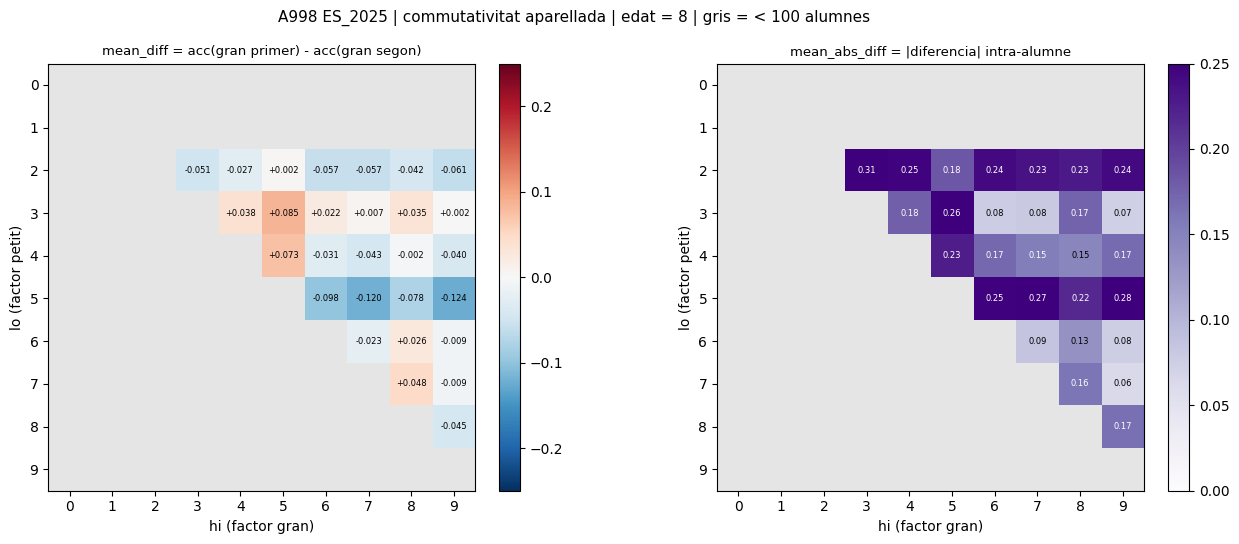

Plot -> descriptive\plots\a998_commutativity_age08.png


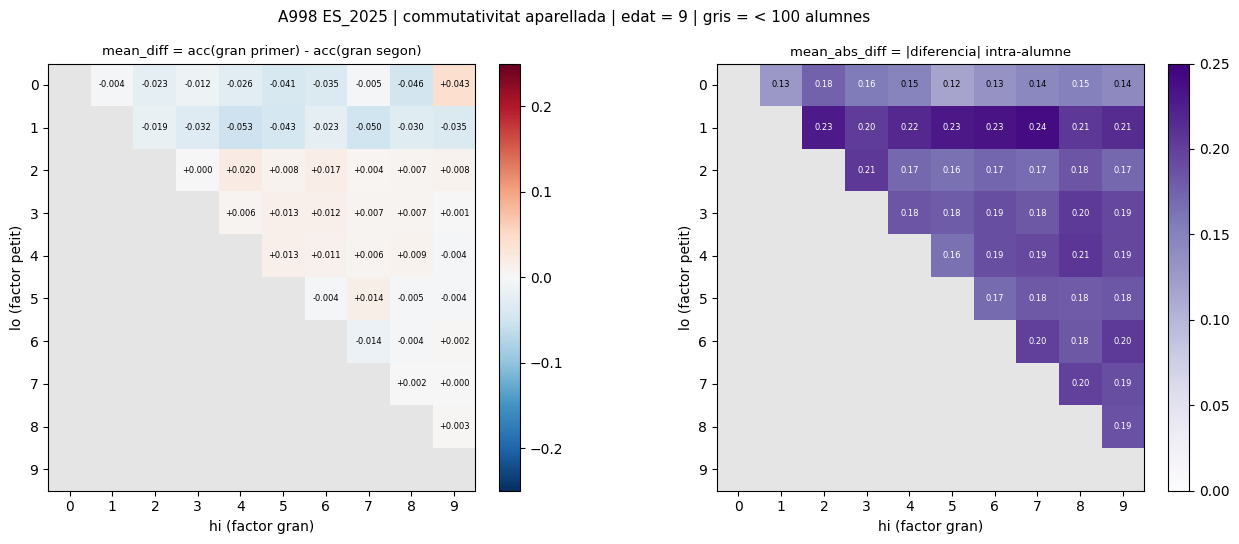

Plot -> descriptive\plots\a998_commutativity_age09.png


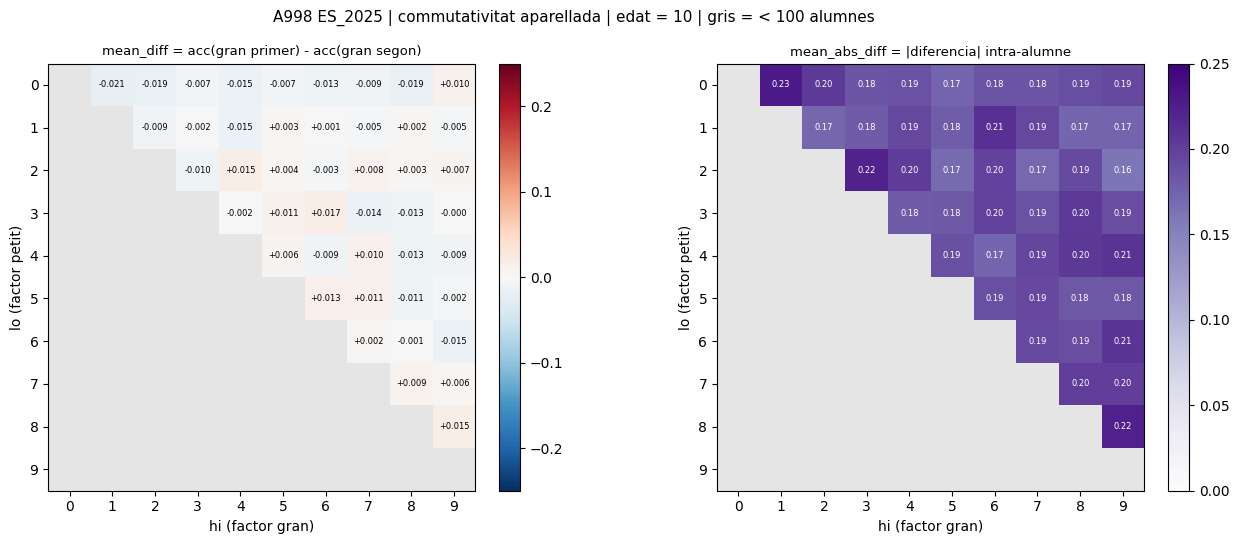

Plot -> descriptive\plots\a998_commutativity_age10.png


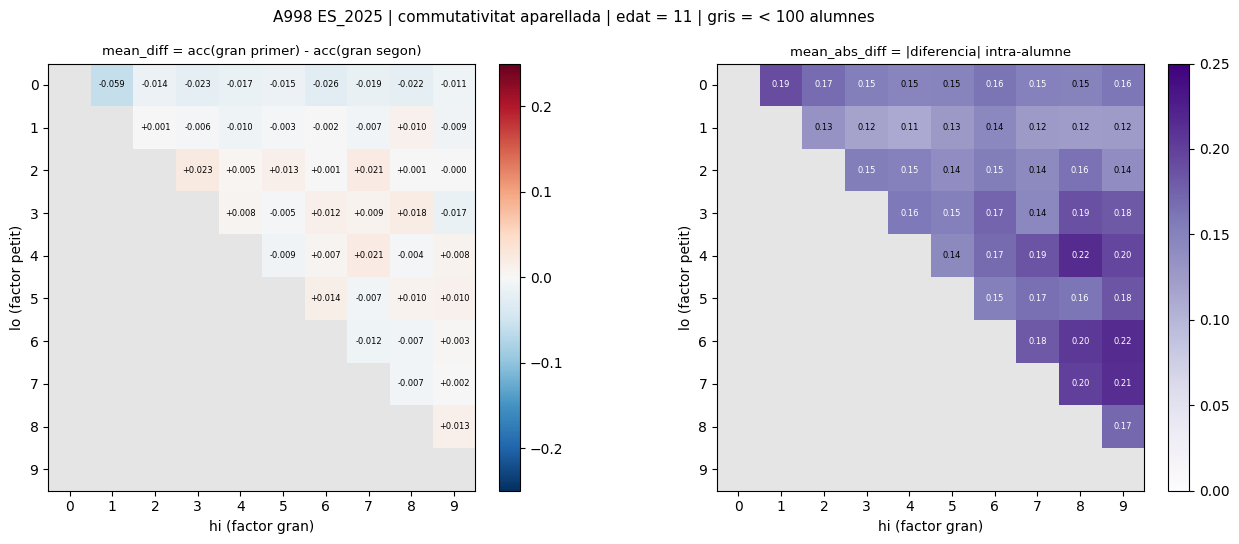

Plot -> descriptive\plots\a998_commutativity_age11.png


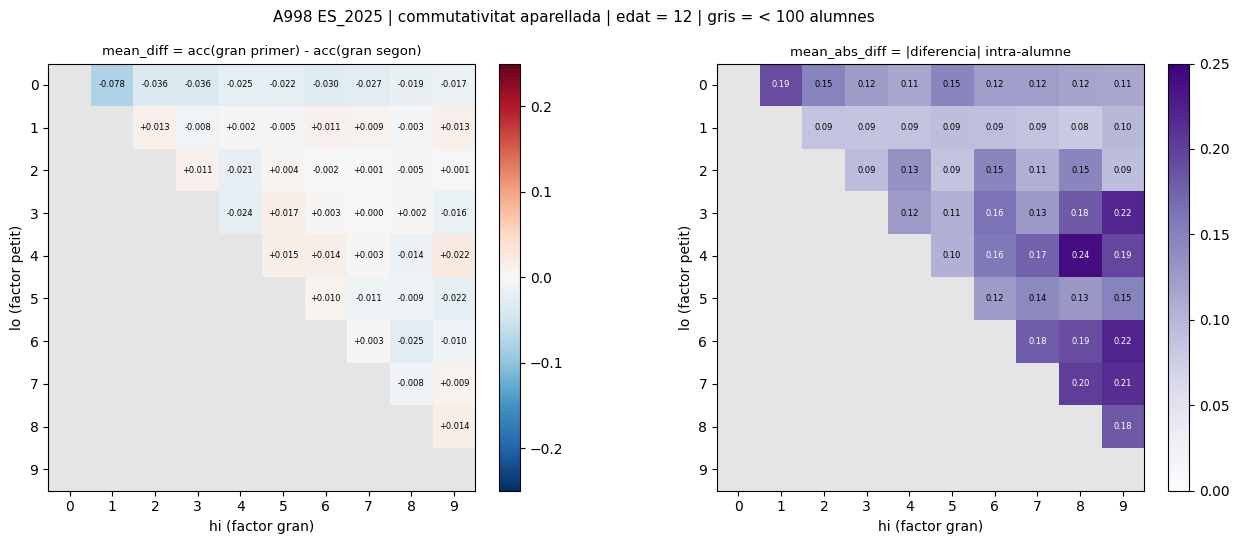

Plot -> descriptive\plots\a998_commutativity_age12.png


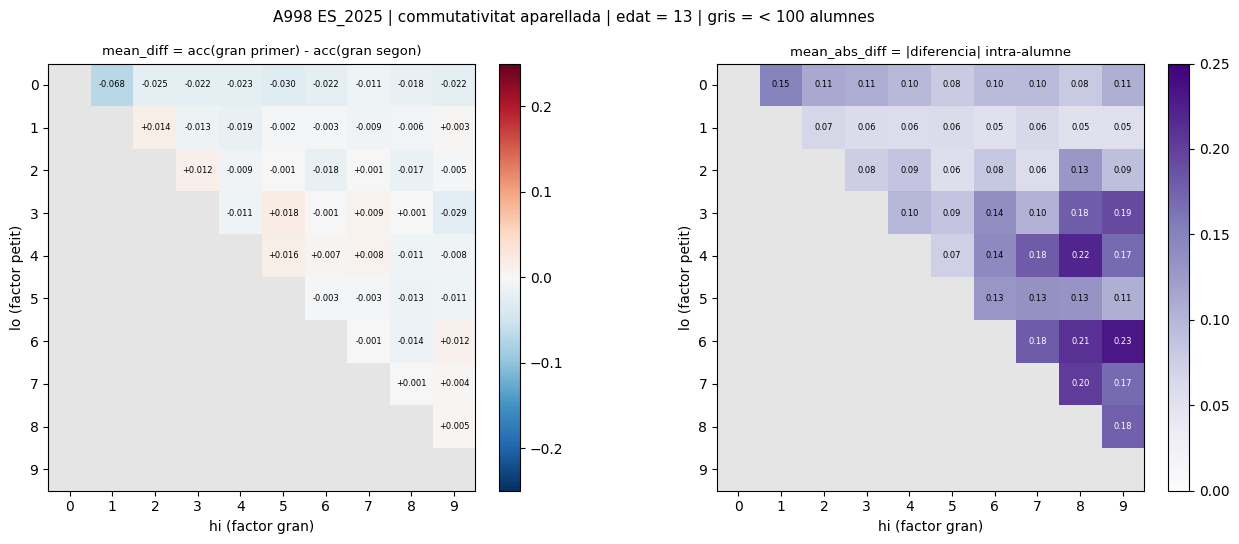

Plot -> descriptive\plots\a998_commutativity_age13.png


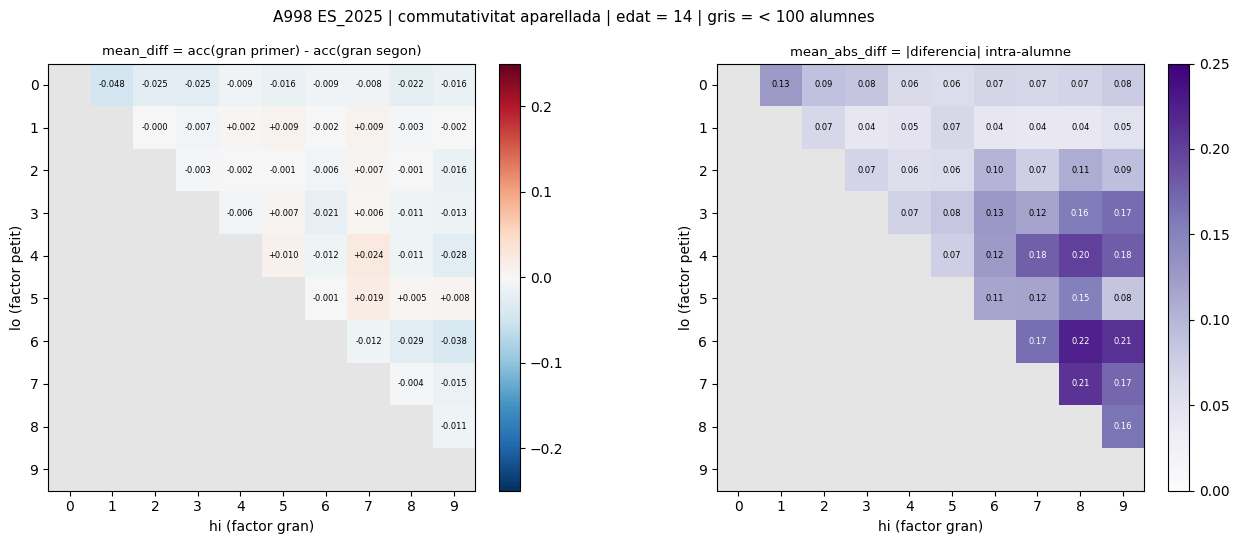

Plot -> descriptive\plots\a998_commutativity_age14.png


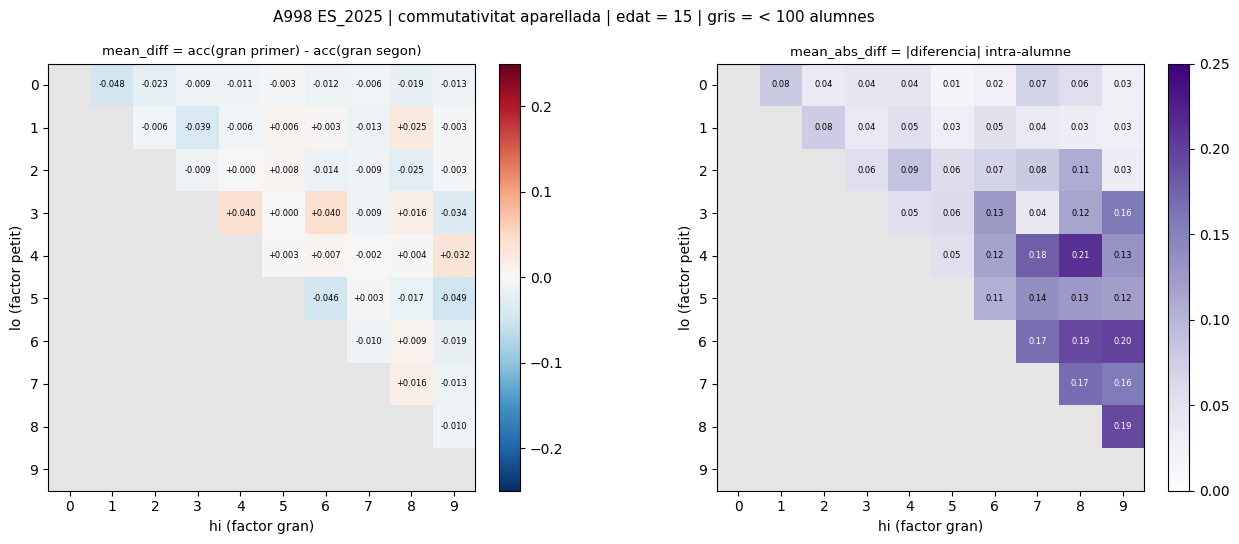

Plot -> descriptive\plots\a998_commutativity_age15.png


In [7]:
# --- un triangle per cada edat (8-15) ------------------------------------
for age in range(8, 16):
    plot_commut(age)

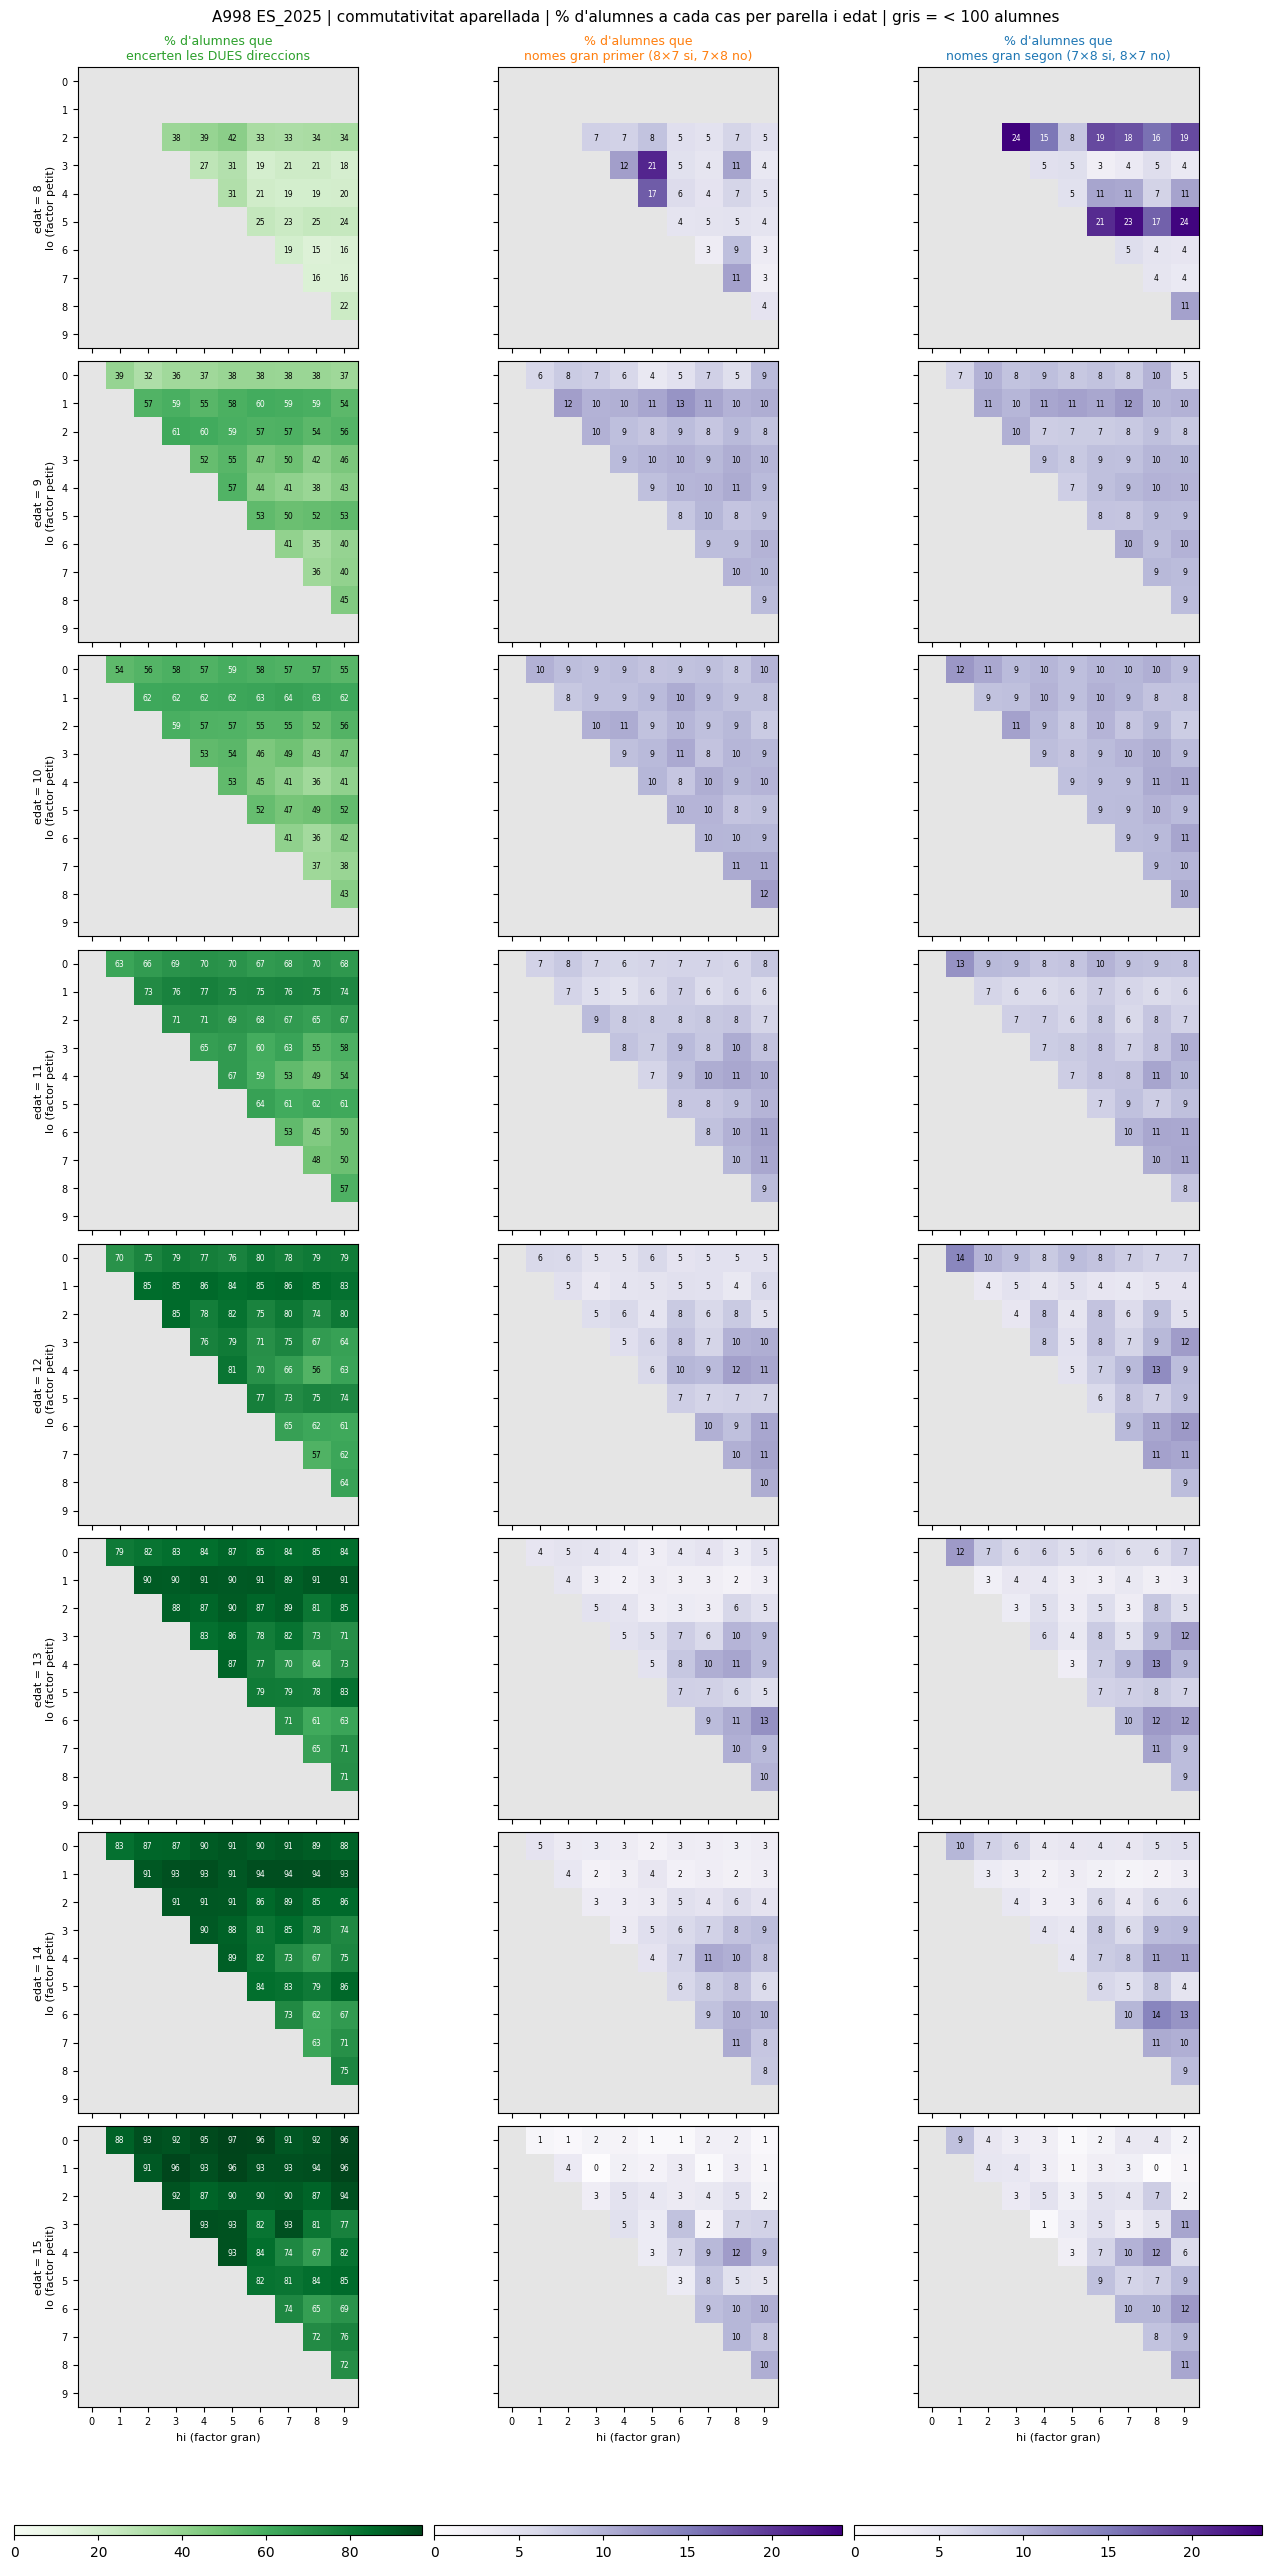

Plot -> descriptive\plots\a998_commutativity_pct_triangles.png
Escala 'les DUES': 0-97% | escala compartida 'nomes una': 0-24%


In [8]:
# --- graella de triangles: % d'alumnes a cada cas, per parella i edat ------
# Mateix format que els triangles de dalt (nomes lo < hi, la meitat superior de
# la diagonal), pero ara una FILA PER EDAT i tres panells de costat, un per cas:
#   encerten les DUES direccions | nomes gran primer | nomes gran segon
# Es la versio per parella del panell 3 de la tendencia: alli es veu QUANTS
# alumnes hi ha a cada cas, aqui QUINES PARELLES els concentren.
#
# ESCALES -------------------------------------------------------------------
# Compartides entre edats (si no, no es poden comparar les files) i, sobretot,
# LES DUES COLUMNES "nomes una direccio" comparteixen escala ENTRE ELLES: la
# pregunta d'aquests dos panells es si una direccio en concentra mes que
# l'altra, i amb escales independents dues xifres diferents es pintarien igual.
# Per aixo tambe fan servir la MATEIXA paleta; el color del titol (taronja /
# blau) es el que lliga cada panell amb la llegenda de la cel.la de tendencia.
# La columna "les DUES" te la seva propia escala perque viu en un altre ordre
# de magnitud (30-90% vs 4-12%).
#
# Gris = casella amb < MIN_STUDENTS alumnes aparellats (ja fora de `valid`).
PCT_PANELS = [
    ("pct_both_right",      "encerten les DUES direccions", "Greens",  "tab:green"),
    ("pct_only_big_first",  "nomes gran primer (8\u00d77 si, 7\u00d78 no)", "Purples", "tab:orange"),
    ("pct_only_big_second", "nomes gran segon (7\u00d78 si, 8\u00d77 no)",  "Purples", "tab:blue"),
]

AGES = sorted(pooled["classroom_course_age"].unique())

# escala 0-max per "les dues"; escala comuna per als dos "nomes una direccio"
BOTH_VMAX = pooled["pct_both_right"].max()
ONLY_VMAX = pooled[["pct_only_big_first", "pct_only_big_second"]].max().max()
SCALES = {"pct_both_right": (0, BOTH_VMAX),
          "pct_only_big_first": (0, ONLY_VMAX),
          "pct_only_big_second": (0, ONLY_VMAX)}

# layout="constrained": amb 24 panells i una barra de color per columna,
# tight_layout deixava un forat gros sota el titol i desplacava les barres.
fig, axes = plt.subplots(len(AGES), 3, figsize=(12.6, 3.2 * len(AGES)),
                         layout="constrained")

ims = {}
for row, age in enumerate(AGES):
    for col, (value_col, title, cmap, title_color) in enumerate(PCT_PANELS):
        ax = axes[row, col]
        vmin, vmax = SCALES[value_col]
        mat = _tri_matrix(age, value_col)
        cmap_obj = plt.get_cmap(cmap).copy()
        cmap_obj.set_bad("0.9")
        im = ax.imshow(mat, cmap=cmap_obj, vmin=vmin, vmax=vmax, origin="upper")
        ims[col] = im
        for a in FACTORS:
            for b in FACTORS:
                if not mat.mask[a, b]:
                    val = mat[a, b]
                    frac = (val - vmin) / (vmax - vmin) if vmax > vmin else 0.5
                    ax.text(b, a, f"{val:.0f}", ha="center", va="center", fontsize=5.5,
                            color="white" if frac > 0.6 else "black")
        ax.set_xticks(FACTORS); ax.set_yticks(FACTORS)
        ax.tick_params(labelsize=7)
        if row == len(AGES) - 1:
            ax.set_xlabel("hi (factor gran)", fontsize=8)
        else:
            ax.set_xticklabels([])
        if col == 0:
            ax.set_ylabel(f"edat = {age}\nlo (factor petit)", fontsize=8)
        else:
            ax.set_yticklabels([])
        if row == 0:
            ax.set_title(f"% d'alumnes que\n{title}", fontsize=9, color=title_color)

# una barra de color per COLUMNA, a sota, perque l'escala es de la columna
# sencera i no de cap panell concret
for col in range(3):
    fig.colorbar(ims[col], ax=axes[:, col], orientation="horizontal",
                 location="bottom", fraction=0.012, pad=0.035, aspect=40)

fig.suptitle(f"A998 {'+'.join(YEARS)} | commutativitat aparellada | % d'alumnes a cada cas "
             f"per parella i edat | gris = < {MIN_STUDENTS} alumnes", fontsize=11)
out_path = HERE / "plots" / "a998_commutativity_pct_triangles.png"
fig.savefig(out_path, dpi=120)
plt.show()
print(f"Plot -> {out_path.relative_to(ROOT)}")
print(f"Escala 'les DUES': 0-{BOTH_VMAX:.0f}% | escala compartida 'nomes una': 0-{ONLY_VMAX:.0f}%")


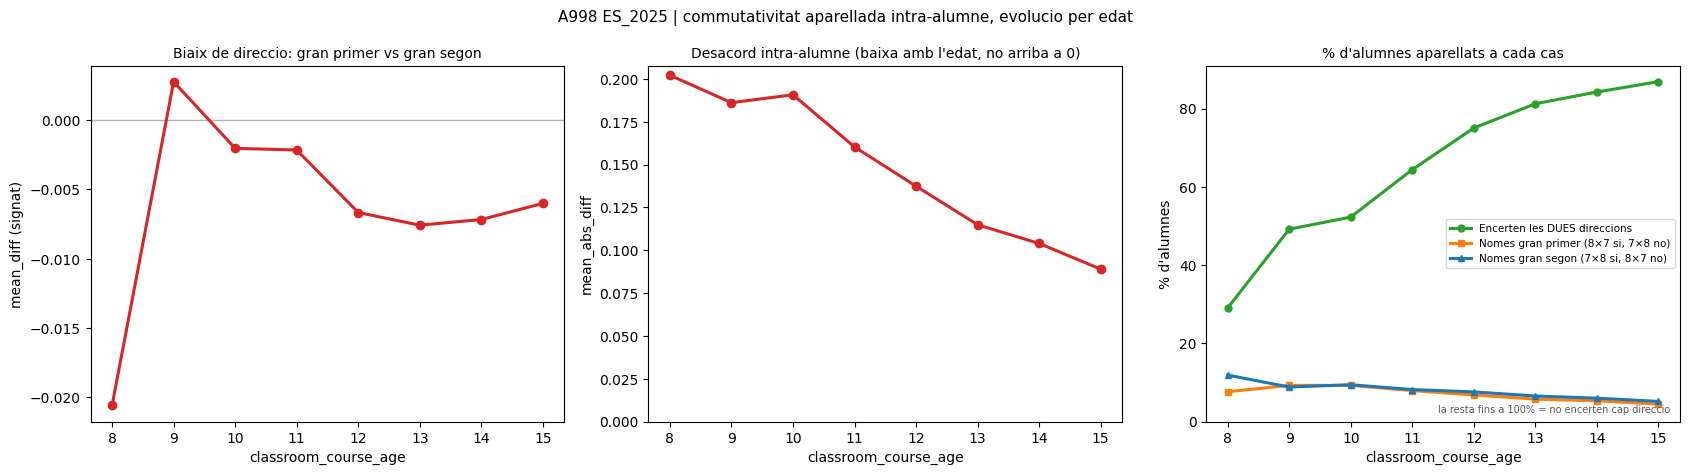

Plot -> descriptive\plots\a998_commutativity_by_age_trend.png


In [9]:
# --- evolucio amb l'edat: biaix, desacord i repartiment d'alumnes ---------
# La pregunta de fons ("quan comencen a saber-se-la") es llegeix com a tendencia.
# Una sola linia per panell: nomes ES_2025 (ES_2024 fora des de 2026-07-30).
#
# PANELL 3 (nou): els MATEIXOS alumnes aparellats dels panells 1 i 2, comptats
# en lloc de promitjats. Es el que fa tangible el que diu mean_abs_diff -- el
# gruix del "no els va igual en les dues direccions" son les dues corbes "nomes
# una direccio", que van gairebe juntes; per aixo la resta de marginals (i el
# mean_diff del panell 1) surt ~0 tot i que hi ha molts alumnes inconsistents.
# La resta fins a 100% son els alumnes que no encerten cap de les dues
# direccions (pct_neither_right, fora del grafic a peticio; surt a la taula).
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

ages = summary.index.to_numpy()

axes[0].axhline(0, color="0.7", lw=1)
axes[0].plot(ages, summary["mean_diff"], "o-", lw=2.2, color="tab:red")
axes[0].set_title("Biaix de direccio: gran primer vs gran segon", fontsize=10)
axes[0].set_ylabel("mean_diff (signat)")

axes[1].plot(ages, summary["mean_abs_diff"], "o-", lw=2.2, color="tab:red")
axes[1].set_ylim(bottom=0)
axes[1].set_title("Desacord intra-alumne (baixa amb l'edat, no arriba a 0)", fontsize=10)
axes[1].set_ylabel("mean_abs_diff")

PCT_STYLE = [
    ("pct_both_right",      "Encerten les DUES direccions",        "tab:green",  "o-"),
    ("pct_only_big_first",  "Nomes gran primer (8\u00d77 si, 7\u00d78 no)", "tab:orange", "s-"),
    ("pct_only_big_second", "Nomes gran segon (7\u00d78 si, 8\u00d77 no)",  "tab:blue",   "^-"),
]
for col, label, color, style in PCT_STYLE:
    axes[2].plot(ages, summary[col], style, lw=2.2, ms=5, color=color, label=label)
axes[2].set_ylim(bottom=0)
axes[2].set_title("% d'alumnes aparellats a cada cas", fontsize=10)
axes[2].set_ylabel("% d'alumnes")
axes[2].legend(fontsize=7.5, loc="center right")
axes[2].text(0.98, 0.02,
             "la resta fins a 100% = no encerten cap direccio",
             transform=axes[2].transAxes, ha="right", va="bottom",
             fontsize=7, color="0.35")

for ax in axes:
    ax.set_xlabel("classroom_course_age")
    ax.set_xticks(range(8, 16))

fig.suptitle(f"A998 {'+'.join(YEARS)} | commutativitat aparellada intra-alumne, "
             f"evolucio per edat", fontsize=11)
fig.tight_layout()
out_path = HERE / "plots" / "a998_commutativity_by_age_trend.png"
fig.savefig(out_path, dpi=130)
plt.show()
print(f"Plot -> {out_path.relative_to(ROOT)}")


## Els valors de `mean_diff` son senyal feble o soroll? (test de permutacio)

**Com es diu el que estem mirant.** `mean_diff` es un **efecte de l'ordre dels
operands** (*operand-order effect*): la mateixa parella de factors, presentada
com $a\times b$ o com $b\times a$, dona precisions diferents. Amb el signe fixat
com el tenim (gran primer menys gran segon) es un **biaix d'ordre**: positiu =
els va millor amb el factor gran davant. `mean_abs_diff` no es un biaix sino una
**inconsistencia intra-alumne davant la commutativitat**: mida del desacord
entre les dues direccions, independentment de cap a on vagi.

**El problema.** El biaix d'ordre surt de l'ordre de 0.01 i la inconsistencia de
l'ordre de 0.1. Amb ~660k observacions aparellades, un 0.01 pot ser
perfectament un efecte real i petit... o pot ser el que qualsevol soroll
produiria. Mirant nomes el numero no es pot distingir, i el contrast amb
`mean_abs_diff` no ajuda: son coses diferents, no la mateixa cosa a dues
escales.

**El null.** En lloc d'assumir una distribucio teorica, la construim amb les
mateixes dades. Si la direccio no importa (hipotesi nul.la), aleshores, per a un
alumne concret i una parella concreta, **quin dels seus intents va anar en quina
direccio es intercanviable**: reetiquetar-los no hauria de canviar res. Aixi que:

1. Per a cada (alumne, parella, edat), agafem els seus intents i les seves
   respostes tal com son. No es toca res del contingut.
2. **Barregem nomes l'etiqueta de direccio** dins d'aquest bloc: quants intents
   van a "gran primer" i quants a "gran segon" es manté igual, pero quins encerts
   cauen a cada banda es re-reparteix a l'atzar.
3. Es recalculen `acc_bf*`, `acc_bs*`, `d*` i `|d*|` i s'agrega igual que
   sempre: els heatmaps per parella i edat, i la mitjana per edat.
4. Es repeteix `N_PERM` vegades. La distribucio dels `mean_diff*` es el que
   veuriem **si la direccio no importes gens**, mantenint intactes la capacitat
   de cada alumne, la dificultat de cada parella, el nombre d'intents i la mida
   de mostra de cada casella.

El pas 2 te forma tancada: si l'alumne ha fet $n$ intents en total amb $k$
encerts i $n_{bf}$ eren en direccio "gran primer", el nombre d'encerts que li
toca a aquella direccio sota el null es una **hipergeometrica** $H(k, n-k,
n_{bf})$ -- exactament "reparteix els $k$ encerts entre les dues direccions
sense reposicio". Per aixo no cal barrejar llistes: es una crida vectoritzada i
els `N_PERM` passis son segons, no minuts.

**El p-valor** es bilateral i empiric, per edat:
$p = (1 + \#\{|mean\_diff^*| \ge |mean\_diff_{obs}|\}) / (1 + N_{PERM})$.
El $+1$ evita $p=0$: amb `N_PERM` finit, el minim que es pot afirmar es
$p < 1/N_{PERM}$.

> **Que NO respon aixo.** Aquest null **no serveix per a `mean_abs_diff`**, i el
> motiu es important: quan un alumne te 1 intent per direccio, permutar les
> etiquetes nomes li pot **canviar el signe** de $d$, mai la magnitud. Com que
> aquest es el cas de gairebe tota la mostra, el `mean_abs_diff*` aleatoritzat
> ha de sortir practicament identic a l'observat -- **no perque la
> inconsistencia sigui senyal, sino per construccio**. El grafic el dibuixa
> igualment perque veure-ho es la millor manera de no oblidar-ho, pero
> interpretar aquella coincidencia com a validacio seria un error. (Hi ha un
> desfasament petit i sistematic -- l'observat queda sempre lleugerament per
> sota del null -- que ve nomes dels alumnes amb intents desiguals entre
> direccions, els unics permutables en magnitud: un indici, no una prova.) Per posar a
> prova `mean_abs_diff` cal un null que trenqui el lligam amb l'operacio
> barrejant les respostes d'un alumne **entre parelles diferents** (i que per
> tant necessita els seus intents agrupats per alumne, no per parella): es la
> continuacio natural i queda pendent.


In [10]:
# --- dades per alumne (perfils de resposta) per poder permutar --------------
# Les mitjanes no es poden permutar: cal el que hi ha a dins. Aquesta query torna
# el mateix univers d'alumnes que la principal, pero desagregat per PERFIL DE
# RESPOSTA (n_bf, ok_bf, n_bs, ok_bs) amb el recompte d'alumnes que el
# comparteixen -- ~15k files en lloc de ~660k, i sense identificadors d'alumne.
# Els marcadors {YEARS} i {MIN_ATTEMPTS} es reescriuen igual que a la principal:
# si els dos fitxers no descriuen la MATEIXA poblacio, el test no compara res.
PROF_SQL_PATH = HERE / "queries" / "a998_commutativity_student_profiles.sql"

prof_raw = PROF_SQL_PATH.read_text(encoding="utf-8")
prof_sql, n_p = re.subn(r">= \d+(\s*-- \{MIN_ATTEMPTS\})",
                        f">= {MIN_ATTEMPTS_PER_DIRECTION}\\1", prof_raw)
assert n_p == 2, f"Esperava 2 marcadors -- {{MIN_ATTEMPTS}}, n'he trobat {n_p}"
prof_sql, n_py = re.subn(r"IN \([^)]*\)(\s*-- \{YEARS\})",
                         f"IN ({years_sql})\\1", prof_sql)
assert n_py == 1, f"Esperava 1 marcador -- {{YEARS}}, n'he trobat {n_py}"

prof = cached_query(PROF_SQL_PATH, CACHE_DIR, sql_text=prof_sql)
print(f"Perfils: {len(prof):,} files | alumnes-observacio: {prof['n_students'].sum():,}"
      f" | cache -> {CACHE_DIR.relative_to(ROOT)}/")

# NOMES les caselles que sobreviuen MIN_STUDENTS, per comparar contra el mateix
# `valid` / `pooled` i no contra una poblacio lleugerament diferent.
keys = valid.set_index(["academic_year_id", "lo", "hi", "classroom_course_age"]).index
prof = prof[prof.set_index(["academic_year_id", "lo", "hi", "classroom_course_age"])
                .index.isin(keys)].reset_index(drop=True)

# Expansio a una fila per alumne: cada alumne ha de permutar independentment.
w = prof["n_students"].to_numpy()
N_BF = np.repeat(prof["n_bf"].to_numpy(), w).astype(np.int64)
N_BS = np.repeat(prof["n_bs"].to_numpy(), w).astype(np.int64)
OK_BF = np.repeat(prof["ok_bf"].to_numpy(), w).astype(np.int64)
OK_BS = np.repeat(prof["ok_bs"].to_numpy(), w).astype(np.int64)
K_TOT = OK_BF + OK_BS            # encerts totals de l'alumne a la parella
N_TOT = N_BF + N_BS
AGE = np.repeat(prof["classroom_course_age"].to_numpy(), w).astype(np.int64)
LO = np.repeat(prof["lo"].to_numpy(), w).astype(np.int64)
HI = np.repeat(prof["hi"].to_numpy(), w).astype(np.int64)
print(f"Files per alumne despres d'expandir: {len(N_BF):,}")

# Codis per agregar amb bincount (molt mes rapid que un groupby per repeticio)
AGES_PERM = np.array(sorted(np.unique(AGE)))
age_code = np.searchsorted(AGES_PERM, AGE)
pair_code = LO * 10 + HI
PAIRS_PERM = np.array(sorted(np.unique(pair_code)))
cell_code = np.searchsorted(PAIRS_PERM, pair_code) * len(AGES_PERM) + age_code
CELL_N = np.bincount(cell_code, minlength=len(PAIRS_PERM) * len(AGES_PERM))
AGE_N = np.bincount(age_code, minlength=len(AGES_PERM))


def agg_by_age(d, absd):
    """Mitjana per edat sobre alumnes = la mateixa mitjana ponderada que `summary`."""
    return (np.bincount(age_code, weights=d, minlength=len(AGES_PERM)) / AGE_N,
            np.bincount(age_code, weights=absd, minlength=len(AGES_PERM)) / AGE_N)


def agg_by_cell(d, absd):
    """Mitjanes per (parella, edat) -> dataframe amb el format que espera _tri_matrix."""
    n = len(PAIRS_PERM) * len(AGES_PERM)
    md = np.bincount(cell_code, weights=d, minlength=n)
    ma = np.bincount(cell_code, weights=absd, minlength=n)
    with np.errstate(invalid="ignore", divide="ignore"):
        md, ma = md / CELL_N, ma / CELL_N
    pc = np.repeat(PAIRS_PERM, len(AGES_PERM))
    return pd.DataFrame({
        "lo": pc // 10, "hi": pc % 10,
        "classroom_course_age": np.tile(AGES_PERM, len(PAIRS_PERM)),
        "n_students": CELL_N, "mean_diff": md, "mean_abs_diff": ma,
    }).query("n_students > 0")


# >>> VERIFICACIO: els perfils han de reproduir la query agregada. Si aixo no
# quadra, els perfils descriuen una altra poblacio i tot el test es una fantasia.
d_obs = OK_BF / N_BF - OK_BS / N_BS
obs_by_age = agg_by_age(d_obs, np.abs(d_obs))
gap_diff = np.abs(obs_by_age[0] - summary.loc[AGES_PERM, "mean_diff"].to_numpy()).max()
gap_abs = np.abs(obs_by_age[1] - summary.loc[AGES_PERM, "mean_abs_diff"].to_numpy()).max()
assert gap_diff < 2e-3 and gap_abs < 2e-3, \
    f"Els perfils NO reprodueixen la query agregada (gap {gap_diff:.4f} / {gap_abs:.4f})"
print(f"Verificacio OK: perfils vs query agregada, desviacio maxima per edat "
      f"{max(gap_diff, gap_abs):.5f} (nomes arrodoniment a 4 decimals del SQL).")


Perfils: 12,473 files | alumnes-observacio: 661,530 | cache -> descriptive\cache/
Files per alumne despres d'expandir: 661,513
Verificacio OK: perfils vs query agregada, desviacio maxima per edat 0.00001 (nomes arrodoniment a 4 decimals del SQL).


In [11]:
# --- el permutador: barreja NOMES l'etiqueta de direccio -------------------
# Per a cada alumne i parella: reparteix els seus K encerts entre les dues
# direccions sense reposicio, mantenint N_BF i N_BS. Aixo es una hipergeometrica,
# i es exactament permutar quines respostes van a quina direccio.
N_PERM = 10000
SEED = 20260730          # llavor fixa: els grafics es poden reproduir

rng = np.random.default_rng(SEED)

def permute_once():
    ok_bf_star = rng.hypergeometric(K_TOT, N_TOT - K_TOT, N_BF)
    d = ok_bf_star / N_BF - (K_TOT - ok_bf_star) / N_BS
    return d, np.abs(d)


null_diff = np.empty((N_PERM, len(AGES_PERM)))
null_abs = np.empty((N_PERM, len(AGES_PERM)))
for r in range(N_PERM):
    d_star, absd_star = permute_once()
    null_diff[r], null_abs[r] = agg_by_age(d_star, absd_star)

obs_diff, obs_abs = obs_by_age

# p bilateral empiric: quantes permutacions donen un biaix igual o mes extrem
p_diff = (1 + (np.abs(null_diff) >= np.abs(obs_diff)).sum(axis=0)) / (1 + N_PERM)
p_abs = (1 + (null_abs >= obs_abs).sum(axis=0)) / (1 + N_PERM)

perm_summary = pd.DataFrame({
    "mean_diff_obs": obs_diff,
    "null_mitjana": null_diff.mean(axis=0),
    "null_p2.5": np.percentile(null_diff, 2.5, axis=0),
    "null_p97.5": np.percentile(null_diff, 97.5, axis=0),
    "p_valor": p_diff,
    "mean_abs_obs": obs_abs,
    "null_abs_mitjana": null_abs.mean(axis=0),
    "p_valor_abs": p_abs,
}, index=AGES_PERM)
perm_summary.index.name = "classroom_course_age"

print(f"NULL A (permutacio de l'etiqueta de direccio) | N_PERM = {N_PERM} | seed = {SEED}")
print(perm_summary.round(4).to_string())

print("\n>>> COM LLEGIR-HO")
print("El null de mean_diff esta centrat a ~0 (ha de ser-ho: la permutacio no")
print("privilegia cap direccio) i la seva amplada 2.5-97.5% diu quant es mou el")
print("biaix nomes per atzar amb aquesta mida de mostra.")
for age in AGES_PERM:
    r = perm_summary.loc[age]
    width = r["null_p97.5"] - r["null_p2.5"]
    veredicte = ("FORA del null" if r["p_valor"] < 0.05 else "dins del null")
    print(f"  edat {age}: obs {r['mean_diff_obs']:+.4f} | null +-"
          f"{width / 2:.4f} | p = {r['p_valor']:.3f} -> {veredicte}")
print("\nI el recordatori del markdown, ara amb numeros: mean_abs_diff observat vs")
print("aleatoritzat es practicament el mateix numero a cada edat")
print(f"(desviacio maxima {np.abs(obs_abs - null_abs.mean(axis=0)).max():.4f}),")
print("perque amb 1 intent per direccio permutar nomes canvia el SIGNE de d.")
print("Aixo NO valida mean_abs_diff: nomes ensenya que aquest null no el pot tocar.")
print("(p_valor_abs es d'UNA cua -- 'mes inconsistencia que l'atzar' -- i surt ~1")
print("perque l'observat queda per SOTA del null, no per sobre.)")
gap = null_abs.mean(axis=0) - obs_abs
print(f"\nDetall que si val la pena: el desfasament va SEMPRE en el mateix sentit,")
print(f"l'observat per sota del null a totes les edats (+{gap.min():.4f} a +{gap.max():.4f}).")
print("Ve de la minoria d'alumnes amb intents desiguals entre direccions (n_bf !=")
print("n_bs), els unics als quals la permutacio SI pot canviar la magnitud de d.")
print("Es un indici -- no una prova -- que part de la consistencia es real: mesurat")
print("sobre nomes aquest subconjunt, i per aixo cal el null entre parelles.")

NULL A (permutacio de l'etiqueta de direccio) | N_PERM = 10000 | seed = 20260730
                      mean_diff_obs  null_mitjana  null_p2.5  null_p97.5  p_valor  mean_abs_obs  null_abs_mitjana  p_valor_abs
classroom_course_age                                                                                                          
8                           -0.0206           0.0    -0.0021      0.0022   0.0001        0.2021            0.2029       0.9983
9                            0.0027          -0.0    -0.0019      0.0019   0.0045        0.1861            0.1931       1.0000
10                          -0.0021          -0.0    -0.0027      0.0027   0.1297        0.1907            0.1946       1.0000
11                          -0.0022           0.0    -0.0023      0.0024   0.0686        0.1603            0.1632       1.0000
12                          -0.0067          -0.0    -0.0032      0.0031   0.0002        0.1374            0.1393       1.0000
13                          -0

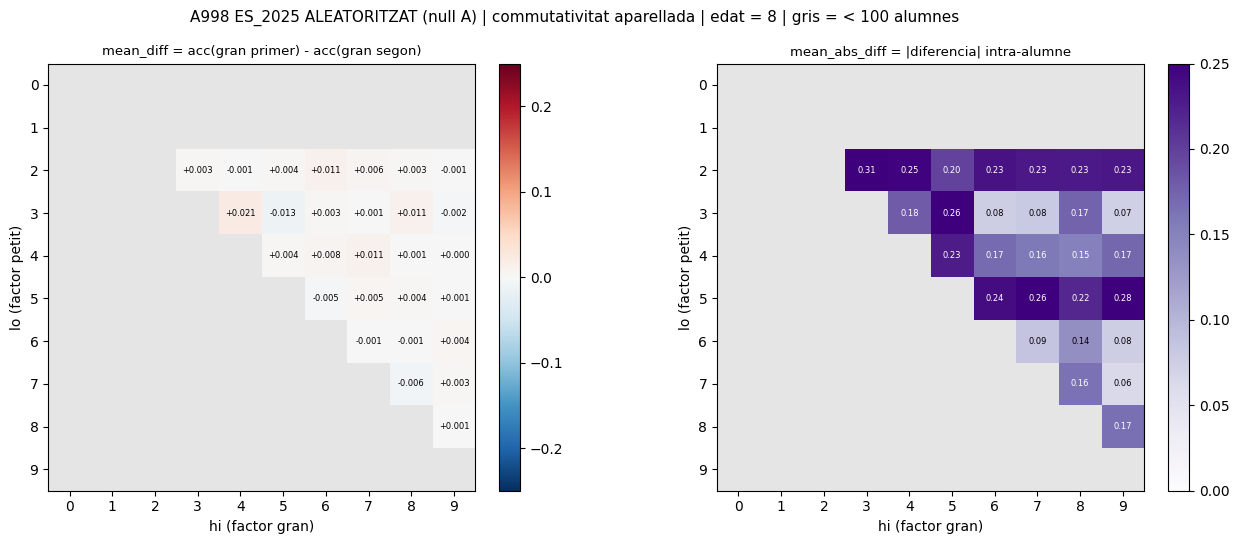

Plot -> descriptive\plots\a998_commutativity_age08_shuffled.png


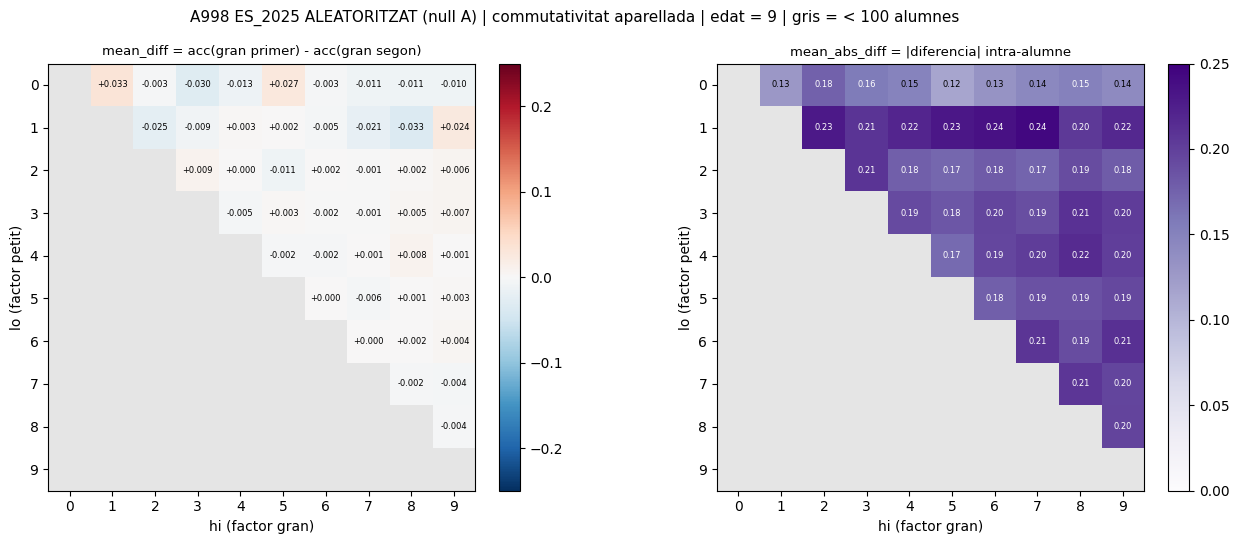

Plot -> descriptive\plots\a998_commutativity_age09_shuffled.png


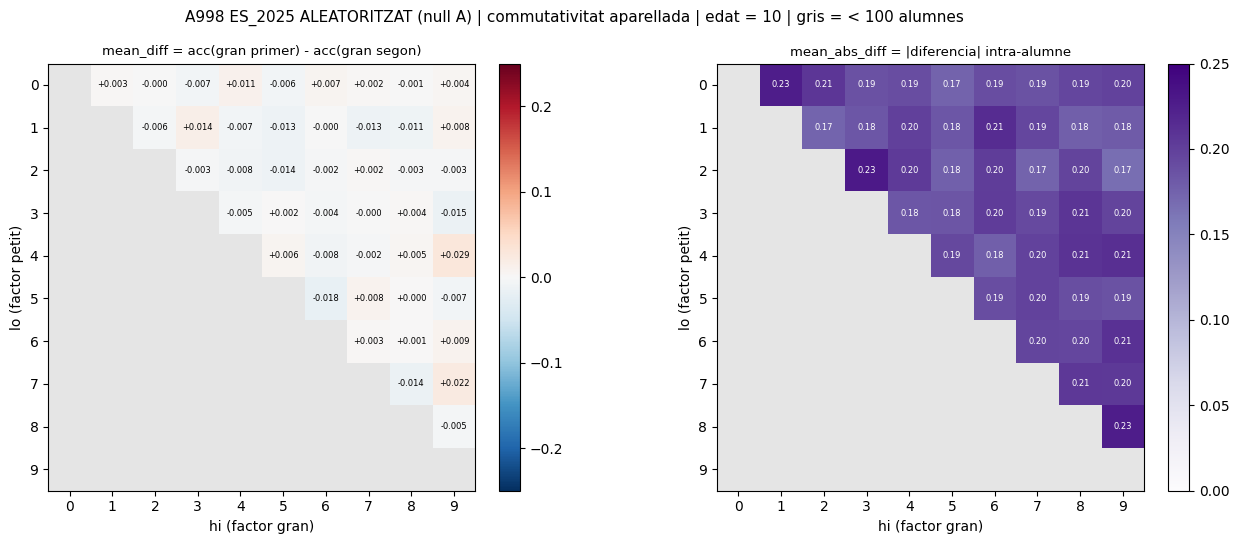

Plot -> descriptive\plots\a998_commutativity_age10_shuffled.png


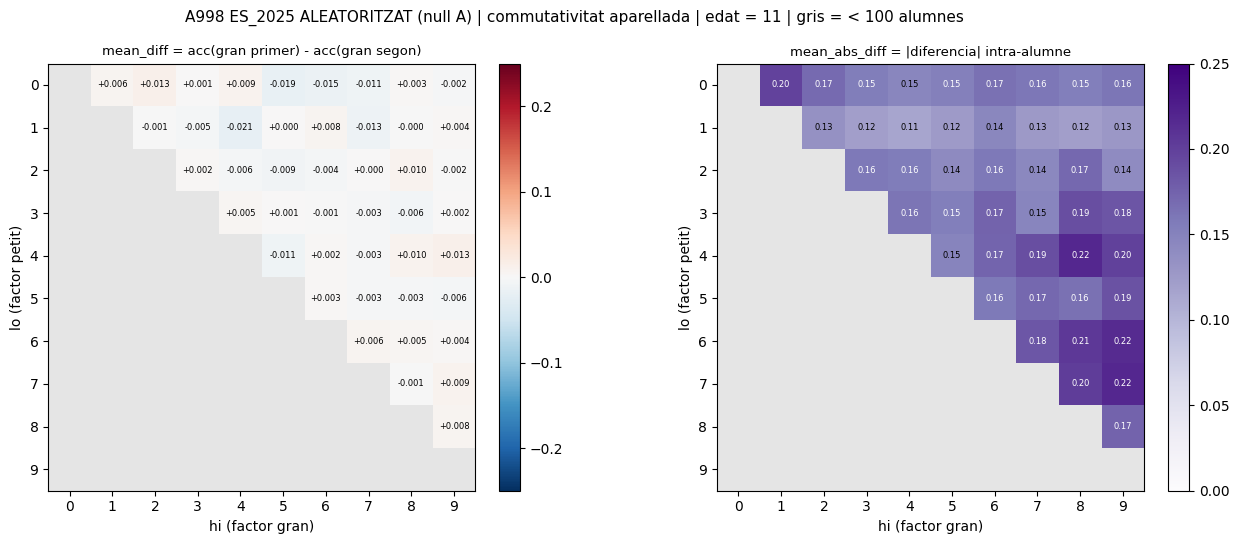

Plot -> descriptive\plots\a998_commutativity_age11_shuffled.png


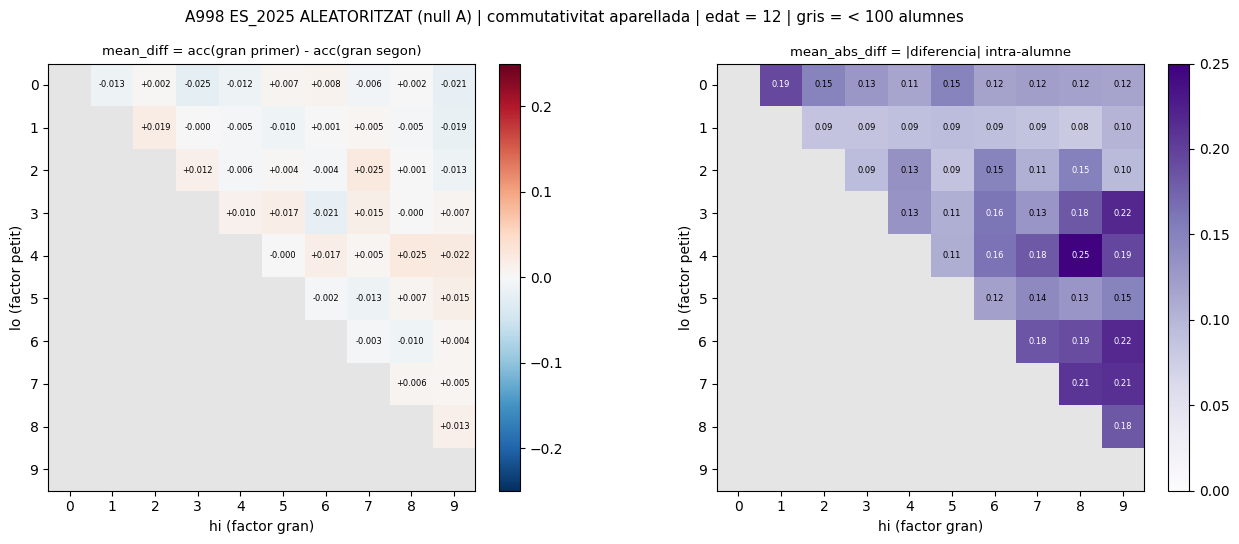

Plot -> descriptive\plots\a998_commutativity_age12_shuffled.png


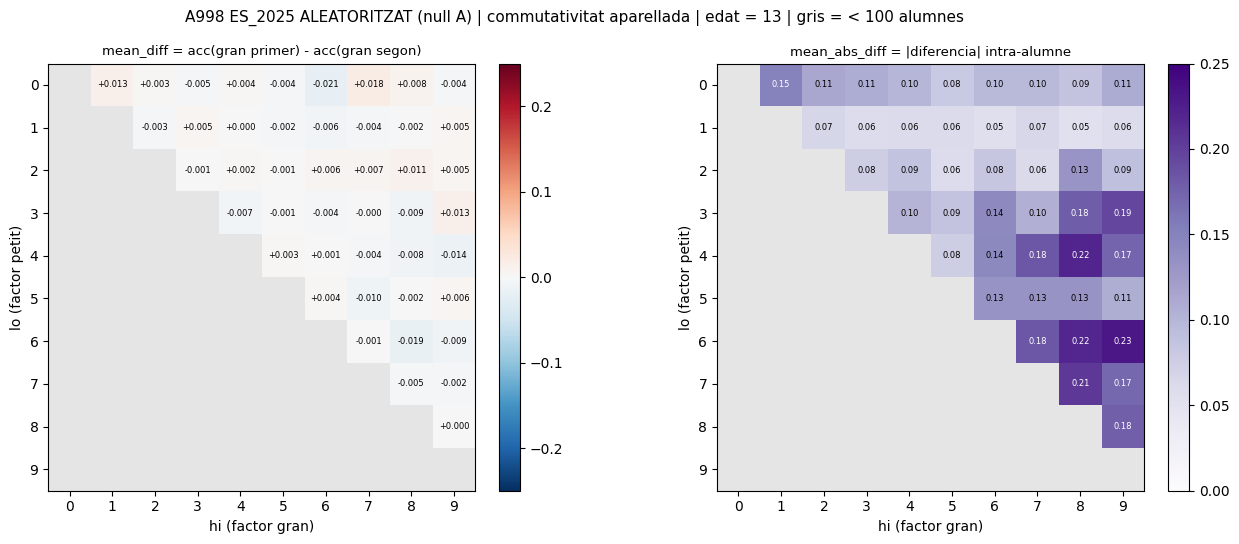

Plot -> descriptive\plots\a998_commutativity_age13_shuffled.png


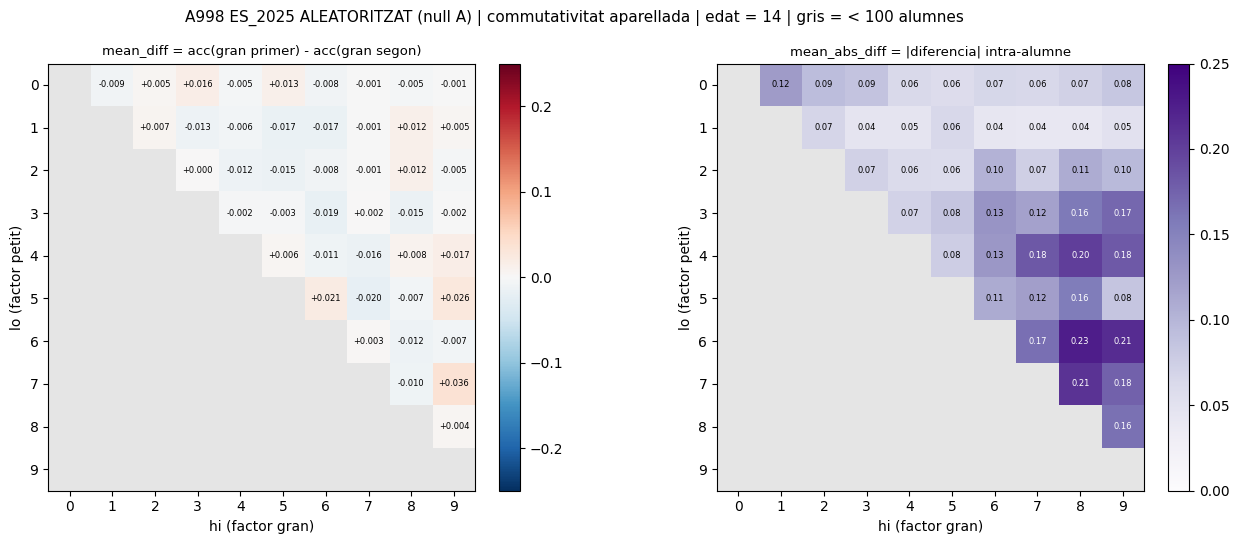

Plot -> descriptive\plots\a998_commutativity_age14_shuffled.png


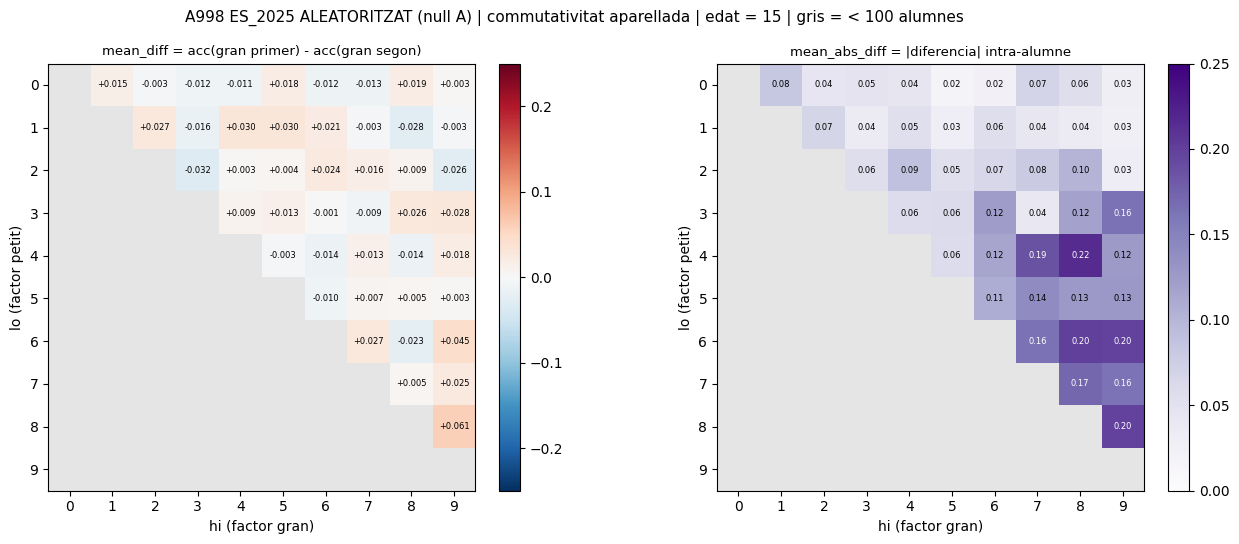

Plot -> descriptive\plots\a998_commutativity_age15_shuffled.png


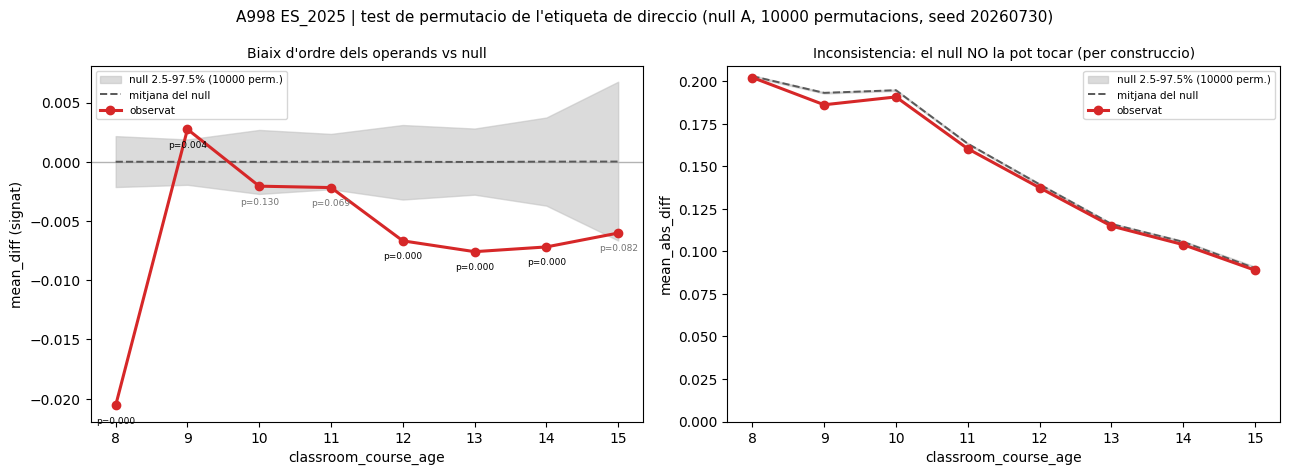

Plot -> descriptive\plots\a998_commutativity_permutation_test.png
Heatmaps aleatoritzats -> plots/a998_commutativity_ageNN_shuffled.png


In [12]:
# --- els mateixos grafics, amb dades aleatoritzades ------------------------
# Una unica repeticio (la primera de la mateixa llavor) pels heatmaps: es la
# comparacio a ull. Mateixa funcio plot_commut, mateixes escales fixes +-0.25 i
# 0-0.25, nomes canvia el dataframe -> qualsevol diferencia que es vegi es de les
# dades, no del format.
rng = np.random.default_rng(SEED)
d_star, absd_star = permute_once()
pooled_shuffled = agg_by_cell(d_star, absd_star)

for age in AGES_PERM:
    plot_commut(age, df=pooled_shuffled, tag="_shuffled",
                extra_title=" ALEATORITZAT (null A)")

# --- tendencia: observat vs banda nul.la ----------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].axhline(0, color="0.7", lw=1)
axes[0].fill_between(AGES_PERM, np.percentile(null_diff, 2.5, axis=0),
                     np.percentile(null_diff, 97.5, axis=0),
                     color="0.75", alpha=0.55, label=f"null 2.5-97.5% ({N_PERM} perm.)")
axes[0].plot(AGES_PERM, null_diff.mean(axis=0), "--", lw=1.4, color="0.35",
             label="mitjana del null")
axes[0].plot(AGES_PERM, obs_diff, "o-", lw=2.2, color="tab:red", label="observat")
axes[0].set_ylabel("mean_diff (signat)")
axes[0].set_title("Biaix d'ordre dels operands vs null", fontsize=10)
for age, obs, p in zip(AGES_PERM, obs_diff, p_diff):
    axes[0].annotate(f"p={p:.3f}", (age, obs), textcoords="offset points",
                     xytext=(0, -13), ha="center", fontsize=6.5,
                     color="black" if p < 0.05 else "0.45")

axes[1].fill_between(AGES_PERM, np.percentile(null_abs, 2.5, axis=0),
                     np.percentile(null_abs, 97.5, axis=0),
                     color="0.75", alpha=0.55, label=f"null 2.5-97.5% ({N_PERM} perm.)")
axes[1].plot(AGES_PERM, null_abs.mean(axis=0), "--", lw=1.4, color="0.35",
             label="mitjana del null")
axes[1].plot(AGES_PERM, obs_abs, "o-", lw=2.2, color="tab:red", label="observat")
axes[1].set_ylim(bottom=0)
axes[1].set_ylabel("mean_abs_diff")
axes[1].set_title("Inconsistencia: el null NO la pot tocar (per construccio)", fontsize=10)

for ax in axes:
    ax.set_xlabel("classroom_course_age")
    ax.set_xticks(range(8, 16))
    ax.legend(fontsize=7.5)

fig.suptitle(f"A998 {'+'.join(YEARS)} | test de permutacio de l'etiqueta de direccio "
             f"(null A, {N_PERM} permutacions, seed {SEED})", fontsize=11)
fig.tight_layout()
out_path = HERE / "plots" / "a998_commutativity_permutation_test.png"
fig.savefig(out_path, dpi=130)
plt.show()
print(f"Plot -> {out_path.relative_to(ROOT)}")
print("Heatmaps aleatoritzats -> plots/a998_commutativity_ageNN_shuffled.png")
